In [1]:

# Analysis Plan:
# This analysis will measure the N-dependence of R_comp numerator and denominator separately
# at resonance peaks versus random ordinates for ζ(s).
#
# Steps:
# 1. Identify top 10 resonance peaks and 10 random ordinates in t∈[5000, 15000]
# 2. For each ordinate, compute at N values {10^5, 2×10^5, 5×10^5, 10^6, 2×10^6}:
# a. Num(N) = |D(t; N)| = |Σ_k S_k(t;N)|
# b. Den(N) = (Σ_k |S_k(t;N)|²)^(1/2)
# 3. Fit power-law model f(N) = c * N^α to both Num(N) and Den(N)
# 4. Statistical comparison of growth exponents using Mann-Whitney U test
#
# Technical requirements:
# - Use Kahan summation for numerical stability
# - Use JIT compilation (numba) for efficiency
# - Compute ω(n) for all n up to max(N)
# - Separate partial sums S_k by ω(n) = k

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import mannwhitneyu
from numba import jit
import time

print("Starting analysis of R_comp numerator and denominator N-dependence...")
print("=" * 80)


Starting analysis of R_comp numerator and denominator N-dependence...


In [2]:

# Pre-compute ω(n) - number of distinct prime factors for all n up to N_max
# This is essential for efficiency per the dataset description

def compute_omega(N_max):
 """Compute ω(n) for all n from 1 to N_max using sieve method."""
 omega = np.zeros(N_max + 1, dtype=np.int32)
 
 # Sieve of Eratosthenes to mark primes and count distinct factors
 for p in range(2, N_max + 1):
 if omega[p] == 0: # p is prime
 # Mark all multiples of p
 for multiple in range(p, N_max + 1, p):
 omega[multiple] += 1
 
 return omega

# Set N_max to the largest N value we'll use
N_max = 2_000_000
print(f"Computing ω(n) for all n up to {N_max:,}...")
start = time.time()
omega_values = compute_omega(N_max)
elapsed = time.time() - start
print(f"Done! Computed in {elapsed:.2f} seconds")
print(f"Sample values: ω(1)={omega_values[1]}, ω(2)={omega_values[2]}, ω(6)={omega_values[6]}, ω(30)={omega_values[30]}")
print()


Computing ω(n) for all n up to 2,000,000...


Done! Computed in 13.85 seconds
Sample values: ω(1)=0, ω(2)=1, ω(6)=2, ω(30)=3



In [3]:

# Implement Kahan-compensated partial sum computation with S_k decomposition
# Using numba JIT compilation for speed

@jit(nopython=True)
def compute_S_k_sums(t, N, omega_arr, max_k=20):
 """
 Compute S_k(t;N) sums for zeta function where S_k = Σ_{n≤N, ω(n)=k} n^{-1/2-it}
 
 Args:
 t: ordinate value
 N: truncation length
 omega_arr: pre-computed array of ω(n) values
 max_k: maximum k value to track
 
 Returns:
 S_k: complex array of partial sums for each k value
 """
 # Initialize arrays for Kahan summation
 S_k_real = np.zeros(max_k + 1, dtype=np.float64)
 S_k_imag = np.zeros(max_k + 1, dtype=np.float64)
 comp_real = np.zeros(max_k + 1, dtype=np.float64)
 comp_imag = np.zeros(max_k + 1, dtype=np.float64)
 
 # For zeta function, a_n = 1 for all n
 for n in range(1, N + 1):
 k = omega_arr[n]
 if k > max_k:
 k = max_k # Bin all large k together
 
 # Compute term: n^{-1/2-it} = n^{-1/2} * exp(-it*log(n))
 n_sqrt = np.sqrt(n)
 phase = -t * np.log(n)
 
 # Real and imaginary parts of the term
 term_real = np.cos(phase) / n_sqrt
 term_imag = np.sin(phase) / n_sqrt
 
 # Kahan summation for real part
 y_real = term_real - comp_real[k]
 temp_real = S_k_real[k] + y_real
 comp_real[k] = (temp_real - S_k_real[k]) - y_real
 S_k_real[k] = temp_real
 
 # Kahan summation for imaginary part
 y_imag = term_imag - comp_imag[k]
 temp_imag = S_k_imag[k] + y_imag
 comp_imag[k] = (temp_imag - S_k_imag[k]) - y_imag
 S_k_imag[k] = temp_imag
 
 # Combine into complex array
 S_k = S_k_real + 1j * S_k_imag
 return S_k

print("JIT-compiled S_k computation function defined.")
print("Testing with a small example...")

# Test run to trigger JIT compilation
test_S_k = compute_S_k_sums(100.0, 1000, omega_values, max_k=20)
print(f"Test computation: |S_1| = {np.abs(test_S_k[1]):.4f}, |S_2| = {np.abs(test_S_k[2]):.4f}")
print()


JIT-compiled S_k computation function defined.
Testing with a small example...


Test computation: |S_1| = 1.8372, |S_2| = 0.7723



In [4]:

# Step 1: Identify top 10 resonance peaks and 10 random ordinates in t∈[5000, 15000]
# We'll do a coarse scan first to find peaks, per dataset description

print("Step 1: Identifying resonance peaks in t ∈ [5000, 15000]")
print("-" * 80)

# Coarse scan parameters
t_min, t_max = 5000, 15000
N_scan = 100_000 # Use moderate N for initial scan
dt_scan = 10 # Coarse spacing

print(f"Running coarse scan with N={N_scan:,} and dt={dt_scan}...")
t_scan = np.arange(t_min, t_max, dt_scan)

# Compute |D(t;N)| for each t value
D_magnitudes = np.zeros(len(t_scan))

start = time.time()
for i, t in enumerate(t_scan):
 S_k = compute_S_k_sums(t, N_scan, omega_values, max_k=20)
 D_t = np.sum(S_k) # Total sum is Σ_k S_k
 D_magnitudes[i] = np.abs(D_t)
 
 if (i + 1) % 100 == 0:
 print(f" Processed {i+1}/{len(t_scan)} t values...", end='\r')

elapsed = time.time() - start
print(f"\nCoarse scan completed in {elapsed:.1f} seconds")
print(f"Magnitude range: [{D_magnitudes.min():.3f}, {D_magnitudes.max():.3f}]")
print()


Step 1: Identifying resonance peaks in t ∈ [5000, 15000]
--------------------------------------------------------------------------------
Running coarse scan with N=100,000 and dt=10...


 Processed 1000/1000 t values...
Coarse scan completed in 4.9 seconds
Magnitude range: [0.007, 12.641]



In [5]:

# Find local maxima (peaks) in the scan
from scipy.signal import find_peaks

# Find peaks with some minimum prominence to get significant resonances
peaks_idx, properties = find_peaks(D_magnitudes, prominence=1.0, distance=5)

print(f"Found {len(peaks_idx)} peaks with prominence >= 1.0")
print()

# Get peak heights and sort by magnitude
peak_heights = D_magnitudes[peaks_idx]
peak_t_values = t_scan[peaks_idx]

# Sort by height (descending) and take top 10
sorted_indices = np.argsort(peak_heights)[::-1]
top_10_indices = sorted_indices[:10]

t_peaks = peak_t_values[top_10_indices]
peak_mags = peak_heights[top_10_indices]

print("Top 10 resonance peaks:")
print(" Rank t value |D(t)|")
print(" " + "-" * 30)
for i, (t, mag) in enumerate(zip(t_peaks, peak_mags), 1):
 print(f" {i:2d} {t:7.1f} {mag:6.3f}")
print()

# Select 10 random ordinates (avoiding peaks)
# Choose ordinates that are local minima or at least far from peaks
np.random.seed(42) # For reproducibility
min_distance_from_peaks = 100 # At least this far from any peak

# Create mask of "safe" regions (far from peaks)
safe_mask = np.ones(len(t_scan), dtype=bool)
for peak_idx in peaks_idx:
 start_idx = max(0, peak_idx - min_distance_from_peaks // dt_scan)
 end_idx = min(len(t_scan), peak_idx + min_distance_from_peaks // dt_scan)
 safe_mask[start_idx:end_idx] = False

safe_indices = np.where(safe_mask)[0]
random_indices = np.random.choice(safe_indices, size=10, replace=False)
t_random = t_scan[random_indices]
random_mags = D_magnitudes[random_indices]

print("10 random ordinates (away from peaks):")
print(" Index t value |D(t)|")
print(" " + "-" * 30)
for i, (t, mag) in enumerate(zip(t_random, random_mags), 1):
 print(f" {i:2d} {t:7.1f} {mag:6.3f}")
print()


Found 115 peaks with prominence >= 1.0

Top 10 resonance peaks:
 Rank t value |D(t)|
 ------------------------------
 1 5130.0 12.641
 2 6200.0 12.177
 3 8230.0 11.967
 4 13280.0 11.833
 5 6680.0 11.644
 6 13000.0 11.605
 7 11330.0 11.449
 8 14830.0 10.954
 9 13480.0 10.933
 10 11540.0 10.733



ValueError: 'a' cannot be empty unless no samples are taken

In [6]:

# Fix: The safe region is too restrictive. Use smaller distance and check availability
print(f"Number of safe indices: {len(safe_indices)}")

# Try with smaller minimum distance
min_distance_from_peaks = 20 # Smaller distance

safe_mask = np.ones(len(t_scan), dtype=bool)
for peak_idx in peaks_idx:
 start_idx = max(0, peak_idx - min_distance_from_peaks // dt_scan)
 end_idx = min(len(t_scan), peak_idx + min_distance_from_peaks // dt_scan)
 safe_mask[start_idx:end_idx] = False

safe_indices = np.where(safe_mask)[0]
print(f"Number of safe indices with min_distance={min_distance_from_peaks}: {len(safe_indices)}")

if len(safe_indices) >= 10:
 random_indices = np.random.choice(safe_indices, size=10, replace=False)
 t_random = t_scan[random_indices]
 random_mags = D_magnitudes[random_indices]
 
 print("\n10 random ordinates (away from peaks):")
 print(" Index t value |D(t)|")
 print(" " + "-" * 30)
 for i, (t, mag) in enumerate(zip(t_random, random_mags), 1):
 print(f" {i:2d} {t:7.1f} {mag:6.3f}")
else:
 # Just pick random t values from the low-magnitude region
 low_mag_indices = np.where(D_magnitudes < np.median(D_magnitudes))[0]
 random_indices = np.random.choice(low_mag_indices, size=10, replace=False)
 t_random = t_scan[random_indices]
 random_mags = D_magnitudes[random_indices]
 
 print("\n10 random ordinates (from low-magnitude region):")
 print(" Index t value |D(t)|")
 print(" " + "-" * 30)
 for i, (t, mag) in enumerate(zip(t_random, random_mags), 1):
 print(f" {i:2d} {t:7.1f} {mag:6.3f}")

print()


Number of safe indices: 0
Number of safe indices with min_distance=20: 540

10 random ordinates (away from peaks):
 Index t value |D(t)|
 ------------------------------
 1 9130.0 1.505
 2 6450.0 0.366
 3 14690.0 0.839
 4 6700.0 2.094
 5 13690.0 0.956
 6 6530.0 0.705
 7 10410.0 0.957
 8 12740.0 0.367
 9 11180.0 0.087
 10 11990.0 0.039



In [7]:

# Step 2: For each of the 20 ordinates, compute Num(N) and Den(N) for multiple N values

N_values = np.array([100_000, 200_000, 500_000, 1_000_000, 2_000_000])
print(f"Step 2: Computing Num(N) and Den(N) for {len(N_values)} N values")
print(f"N values: {N_values}")
print("-" * 80)

# Store results
all_ordinates = np.concatenate([t_peaks, t_random])
ordinate_types = ['peak'] * len(t_peaks) + ['random'] * len(t_random)

results = {
 'ordinate': [],
 'type': [],
 'N': [],
 'Num': [], # |D(t;N)| = |Σ_k S_k|
 'Den': [] # sqrt(Σ_k |S_k|^2)
}

print(f"Computing for {len(all_ordinates)} ordinates...\n")

for idx, (t_val, ord_type) in enumerate(zip(all_ordinates, ordinate_types)):
 print(f"Ordinate {idx+1}/{len(all_ordinates)}: t={t_val:.1f} ({ord_type})")
 
 for N in N_values:
 # Compute S_k sums
 S_k = compute_S_k_sums(t_val, N, omega_values, max_k=20)
 
 # Numerator: |Σ_k S_k|
 D_total = np.sum(S_k)
 Num = np.abs(D_total)
 
 # Denominator: sqrt(Σ_k |S_k|^2)
 sum_squared = np.sum(np.abs(S_k)**2)
 Den = np.sqrt(sum_squared)
 
 # Store results
 results['ordinate'].append(t_val)
 results['type'].append(ord_type)
 results['N'].append(N)
 results['Num'].append(Num)
 results['Den'].append(Den)
 
 print(f" Num range: [{min([r for r, t in zip(results['Num'], results['ordinate']) if t == t_val]):.3f}, "
 f"{max([r for r, t in zip(results['Num'], results['ordinate']) if t == t_val]):.3f}]")
 print(f" Den range: [{min([r for r, t in zip(results['Den'], results['ordinate']) if t == t_val]):.3f}, "
 f"{max([r for r, t in zip(results['Den'], results['ordinate']) if t == t_val]):.3f}]")
 print()

print("Data collection complete!")
print(f"Total data points: {len(results['N'])}")
print()


Step 2: Computing Num(N) and Den(N) for 5 N values
N values: [ 100000 200000 500000 1000000 2000000]
--------------------------------------------------------------------------------
Computing for 20 ordinates...

Ordinate 1/20: t=5130.0 (peak)
 Num range: [12.496, 12.683]
 Den range: [6.190, 6.452]

Ordinate 2/20: t=6200.0 (peak)


 Num range: [12.140, 12.225]
 Den range: [7.196, 7.627]

Ordinate 3/20: t=8230.0 (peak)
 Num range: [11.966, 12.104]
 Den range: [6.507, 6.830]

Ordinate 4/20: t=13280.0 (peak)
 Num range: [11.833, 11.885]
 Den range: [6.323, 6.425]

Ordinate 5/20: t=6680.0 (peak)


 Num range: [11.626, 11.712]
 Den range: [5.661, 5.995]

Ordinate 6/20: t=13000.0 (peak)
 Num range: [11.605, 11.658]
 Den range: [7.092, 7.274]

Ordinate 7/20: t=11330.0 (peak)
 Num range: [11.406, 11.524]
 Den range: [5.333, 5.523]

Ordinate 8/20: t=14830.0 (peak)


 Num range: [10.945, 10.994]
 Den range: [9.217, 9.399]

Ordinate 9/20: t=13480.0 (peak)
 Num range: [10.895, 10.942]
 Den range: [5.141, 5.398]

Ordinate 10/20: t=11540.0 (peak)
 Num range: [10.733, 10.810]
 Den range: [5.374, 5.528]

Ordinate 11/20: t=9130.0 (random)


 Num range: [1.409, 1.606]
 Den range: [1.662, 2.305]

Ordinate 12/20: t=6450.0 (random)
 Num range: [0.310, 0.591]
 Den range: [2.545, 2.744]

Ordinate 13/20: t=14690.0 (random)
 Num range: [0.782, 0.903]
 Den range: [1.469, 1.796]

Ordinate 14/20: t=6700.0 (random)


 Num range: [2.054, 2.283]
 Den range: [1.261, 1.635]

Ordinate 15/20: t=13690.0 (random)
 Num range: [0.904, 1.012]
 Den range: [1.495, 1.920]

Ordinate 16/20: t=6530.0 (random)


 Num range: [0.452, 0.794]
 Den range: [1.827, 1.948]

Ordinate 17/20: t=10410.0 (random)
 Num range: [0.826, 1.013]
 Den range: [1.760, 1.981]

Ordinate 18/20: t=12740.0 (random)


 Num range: [0.296, 0.467]
 Den range: [1.279, 2.159]

Ordinate 19/20: t=11180.0 (random)
 Num range: [0.033, 0.190]
 Den range: [3.121, 3.563]

Ordinate 20/20: t=11990.0 (random)
 Num range: [0.017, 0.098]
 Den range: [2.889, 3.574]

Data collection complete!
Total data points: 100



In [8]:

# Step 3: Fit power-law model f(N) = c * N^α to Num(N) and Den(N) for each ordinate

import pandas as pd
from scipy.optimize import curve_fit

def power_law(N, c, alpha):
 """Power law model: f(N) = c * N^alpha"""
 return c * N**alpha

# Convert results to DataFrame for easier processing
df = pd.DataFrame(results)

print("Step 3: Fitting power-law models")
print("-" * 80)

fit_results = {
 'ordinate': [],
 'type': [],
 'alpha_num': [],
 'alpha_den': [],
 'c_num': [],
 'c_den': []
}

for t_val in all_ordinates:
 # Extract data for this ordinate
 mask = df['ordinate'] == t_val
 ord_data = df[mask]
 ord_type = ord_data['type'].iloc[0]
 
 N_arr = ord_data['N'].values
 Num_arr = ord_data['Num'].values
 Den_arr = ord_data['Den'].values
 
 # Fit power law to Num(N)
 try:
 popt_num, _ = curve_fit(power_law, N_arr, Num_arr, p0=[1.0, 0.0])
 c_num, alpha_num = popt_num
 except:
 c_num, alpha_num = np.nan, np.nan
 
 # Fit power law to Den(N)
 try:
 popt_den, _ = curve_fit(power_law, N_arr, Den_arr, p0=[1.0, 0.0])
 c_den, alpha_den = popt_den
 except:
 c_den, alpha_den = np.nan, np.nan
 
 fit_results['ordinate'].append(t_val)
 fit_results['type'].append(ord_type)
 fit_results['alpha_num'].append(alpha_num)
 fit_results['alpha_den'].append(alpha_den)
 fit_results['c_num'].append(c_num)
 fit_results['c_den'].append(c_den)

# Convert to DataFrame
fit_df = pd.DataFrame(fit_results)

# Separate by type
peak_fits = fit_df[fit_df['type'] == 'peak']
random_fits = fit_df[fit_df['type'] == 'random']

print("Fit results for PEAK ordinates:")
print(peak_fits[['ordinate', 'alpha_num', 'alpha_den']].to_string(index=False))
print()

print("Fit results for RANDOM ordinates:")
print(random_fits[['ordinate', 'alpha_num', 'alpha_den']].to_string(index=False))
print()

# Summary statistics
print("Summary Statistics:")
print("-" * 80)
print(f"Peak ordinates (n={len(peak_fits)}):")
print(f" α_num: mean={peak_fits['alpha_num'].mean():.6f}, std={peak_fits['alpha_num'].std():.6f}")
print(f" α_den: mean={peak_fits['alpha_den'].mean():.6f}, std={peak_fits['alpha_den'].std():.6f}")
print()
print(f"Random ordinates (n={len(random_fits)}):")
print(f" α_num: mean={random_fits['alpha_num'].mean():.6f}, std={random_fits['alpha_num'].std():.6f}")
print(f" α_den: mean={random_fits['alpha_den'].mean():.6f}, std={random_fits['alpha_den'].std():.6f}")
print()


Step 3: Fitting power-law models
--------------------------------------------------------------------------------
Fit results for PEAK ordinates:
 ordinate alpha_num alpha_den
 5130 -0.002680 0.006862
 6200 0.000628 -0.022512
 8230 0.003388 -0.013866
 13280 0.001395 -0.002673
 6680 0.001339 0.020017
 13000 0.001373 -0.006978
 11330 0.001384 -0.011904
 14830 0.001589 -0.005172
 13480 -0.000915 -0.013804
 11540 0.002470 0.003105

Fit results for RANDOM ordinates:
 ordinate alpha_num alpha_den
 9130 0.008324 -0.095139
 6450 0.110611 0.001768
 14690 0.019413 0.032143
 6700 0.026933 0.080517
 13690 0.001771 0.067078
 6530 -0.056903 0.016080
 10410 -0.022157 0.029160
 12740 0.047880 -0.177763
 11180 0.298816 0.035380
 11990 0.361070 0.065311

Summary Statistics:
--------------------------------------------------------------------------------
Peak ordinates (n=10):
 α_num: mean=0.000997, std=0.001704
 α_den: mean=-0.004693, std=0.012252

Random ordinates (n=10):
 α_num: mean=0.079576, std=0.1

In [9]:

# Step 4: Statistical comparison using Mann-Whitney U test

print("Step 4: Statistical Comparison")
print("=" * 80)

# Extract exponent arrays
alpha_num_peak = peak_fits['alpha_num'].values
alpha_num_rand = random_fits['alpha_num'].values
alpha_den_peak = peak_fits['alpha_den'].values
alpha_den_rand = random_fits['alpha_den'].values

# Mann-Whitney U test for denominator exponents
stat_den, p_den = mannwhitneyu(alpha_den_peak, alpha_den_rand, alternative='less')
print("A. Denominator Exponents (α_den):")
print("-" * 80)
print(f" Hypothesis: α_den_peak < α_den_rand")
print(f" H₀: Distributions are equal")
print(f" H₁: α_den_peak tends to be smaller than α_den_rand")
print()
print(f" Peak ordinates: median = {np.median(alpha_den_peak):.6f}, mean = {np.mean(alpha_den_peak):.6f}")
print(f" Random ordinates: median = {np.median(alpha_den_rand):.6f}, mean = {np.mean(alpha_den_rand):.6f}")
print()
print(f" Mann-Whitney U statistic: {stat_den:.2f}")
print(f" p-value (one-sided, α_den_peak < α_den_rand): {p_den:.4f}")
print()

if p_den < 0.05:
 print(f" ✓ SIGNIFICANT at α=0.05: α_den_peak < α_den_rand")
 print(f" Denominator grows SLOWER at peaks (p={p_den:.4f})")
else:
 print(f" ✗ NOT SIGNIFICANT at α=0.05 (p={p_den:.4f})")

# Also test the opposite direction
stat_den_opp, p_den_opp = mannwhitneyu(alpha_den_peak, alpha_den_rand, alternative='greater')
print(f" p-value (one-sided, α_den_peak > α_den_rand): {p_den_opp:.4f}")

if p_den_opp < 0.05:
 print(f" ✓ SIGNIFICANT at α=0.05: α_den_peak > α_den_rand")
 print(f" Denominator grows FASTER at peaks (p={p_den_opp:.4f})")
else:
 print(f" ✗ NOT SIGNIFICANT at α=0.05 (p={p_den_opp:.4f})")

print()
print()

# Mann-Whitney U test for numerator exponents
stat_num, p_num = mannwhitneyu(alpha_num_peak, alpha_num_rand, alternative='two-sided')
print("B. Numerator Exponents (α_num):")
print("-" * 80)
print(f" Hypothesis: α_num_peak ≠ α_num_rand")
print(f" H₀: Distributions are equal")
print(f" H₁: Distributions differ")
print()
print(f" Peak ordinates: median = {np.median(alpha_num_peak):.6f}, mean = {np.mean(alpha_num_peak):.6f}")
print(f" Random ordinates: median = {np.median(alpha_num_rand):.6f}, mean = {np.mean(alpha_num_rand):.6f}")
print()
print(f" Mann-Whitney U statistic: {stat_num:.2f}")
print(f" p-value (two-sided): {p_num:.4f}")
print()

if p_num < 0.05:
 print(f" ✓ SIGNIFICANT at α=0.05: distributions differ (p={p_num:.4f})")
else:
 print(f" ✗ NOT SIGNIFICANT at α=0.05 (p={p_num:.4f})")

print()
print()


Step 4: Statistical Comparison
A. Denominator Exponents (α_den):
--------------------------------------------------------------------------------
 Hypothesis: α_den_peak < α_den_rand
 H₀: Distributions are equal
 H₁: α_den_peak tends to be smaller than α_den_rand

 Peak ordinates: median = -0.006075, mean = -0.004693
 Random ordinates: median = 0.030651, mean = 0.005453

 Mann-Whitney U statistic: 24.00
 p-value (one-sided, α_den_peak < α_den_rand): 0.0270

 ✓ SIGNIFICANT at α=0.05: α_den_peak < α_den_rand
 Denominator grows SLOWER at peaks (p=0.0270)
 p-value (one-sided, α_den_peak > α_den_rand): 0.9774
 ✗ NOT SIGNIFICANT at α=0.05 (p=0.9774)


B. Numerator Exponents (α_num):
--------------------------------------------------------------------------------
 Hypothesis: α_num_peak ≠ α_num_rand
 H₀: Distributions are equal
 H₁: Distributions differ

 Peak ordinates: median = 0.001378, mean = 0.000997
 Random ordinates: median = 0.023173, mean = 0.079576

 Mann-Whitney U statistic: 22.00


In [10]:

# Additional analysis: Check if the hypothesis is actually supported
# The hypothesis states that Den grows MORE rapidly at peaks, causing faster R_comp decay
# But our results show Den grows SLOWER at peaks!

print("Hypothesis Check:")
print("=" * 80)
print("The research hypothesis states:")
print(" 'At peaks, the denominator sqrt(Σ|S_k|²) grows MORE rapidly with N")
print(" than at random ordinates, causing R_comp to decay faster.'")
print()
print("Our findings:")
print(f" α_den at peaks: median = {np.median(alpha_den_peak):.6f}")
print(f" α_den at random: median = {np.median(alpha_den_rand):.6f}")
print()
print(f" The denominator grows SLOWER at peaks (α_den_peak < α_den_rand, p=0.027)")
print()
print("CONCLUSION: The hypothesis is NOT supported by the data.")
print(" The denominator does NOT grow more rapidly at peaks.")
print(" In fact, it grows slower at peaks than at random ordinates.")
print()
print("=" * 80)
print()

# Let's also check the behavior of R_comp itself
print("Additional Analysis: R_comp behavior")
print("-" * 80)

# Compute R_comp = Num / Den for each ordinate and N
df['R_comp'] = df['Num'] / df['Den']

# Analyze R_comp as a function of N for peaks vs random
print("R_comp values:")
print()
for ord_type in ['peak', 'random']:
 type_data = df[df['type'] == ord_type]
 print(f"{ord_type.upper()} ordinates:")
 
 for N in N_values:
 N_data = type_data[type_data['N'] == N]['R_comp'].values
 print(f" N={N:>9,}: mean={np.mean(N_data):.4f}, median={np.median(N_data):.4f}, std={np.std(N_data):.4f}")
 print()

# Compute average decay rate of R_comp
print("Average R_comp decay with N:")
print("-" * 80)

for t_val, ord_type in zip(all_ordinates, ordinate_types):
 mask = df['ordinate'] == t_val
 ord_data = df[mask].sort_values('N')
 
 N_arr = ord_data['N'].values
 R_comp_arr = ord_data['R_comp'].values
 
 # Fit power law to R_comp
 try:
 popt, _ = curve_fit(power_law, N_arr, R_comp_arr, p0=[1.0, 0.0])
 c_rcomp, alpha_rcomp = popt
 print(f"t={t_val:7.1f} ({ord_type:6s}): α_Rcomp = {alpha_rcomp:8.5f}")
 except:
 print(f"t={t_val:7.1f} ({ord_type:6s}): fit failed")

print()


Hypothesis Check:
The research hypothesis states:
 'At peaks, the denominator sqrt(Σ|S_k|²) grows MORE rapidly with N
 than at random ordinates, causing R_comp to decay faster.'

Our findings:
 α_den at peaks: median = -0.006075
 α_den at random: median = 0.030651

 The denominator grows SLOWER at peaks (α_den_peak < α_den_rand, p=0.027)

CONCLUSION: The hypothesis is NOT supported by the data.
 The denominator does NOT grow more rapidly at peaks.
 In fact, it grows slower at peaks than at random ordinates.


Additional Analysis: R_comp behavior
--------------------------------------------------------------------------------
R_comp values:

PEAK ordinates:
 N= 100,000: mean=1.8131, median=1.9121, std=0.2768
 N= 200,000: mean=1.8225, median=1.9177, std=0.2754
 N= 500,000: mean=1.8357, median=1.9177, std=0.2738
 N=1,000,000: mean=1.8409, median=1.9123, std=0.2708
 N=2,000,000: mean=1.8393, median=1.9120, std=0.2631

RANDOM ordinates:
 N= 100,000: mean=0.4803, median=0.4623, std=0.4585
 N

In [11]:

# Statistical test on R_comp decay rates
fit_results_rcomp = {
 'ordinate': [],
 'type': [],
 'alpha_rcomp': []
}

for t_val, ord_type in zip(all_ordinates, ordinate_types):
 mask = df['ordinate'] == t_val
 ord_data = df[mask].sort_values('N')
 
 N_arr = ord_data['N'].values
 R_comp_arr = ord_data['R_comp'].values
 
 try:
 popt, _ = curve_fit(power_law, N_arr, R_comp_arr, p0=[1.0, 0.0])
 c_rcomp, alpha_rcomp = popt
 except:
 alpha_rcomp = np.nan
 
 fit_results_rcomp['ordinate'].append(t_val)
 fit_results_rcomp['type'].append(ord_type)
 fit_results_rcomp['alpha_rcomp'].append(alpha_rcomp)

rcomp_df = pd.DataFrame(fit_results_rcomp)
peak_rcomp = rcomp_df[rcomp_df['type'] == 'peak']['alpha_rcomp'].values
random_rcomp = rcomp_df[rcomp_df['type'] == 'random']['alpha_rcomp'].values

print("Statistical Comparison of R_comp Exponents:")
print("=" * 80)
print(f"Peak ordinates: median = {np.median(peak_rcomp):.6f}, mean = {np.mean(peak_rcomp):.6f}")
print(f"Random ordinates: median = {np.median(random_rcomp):.6f}, mean = {np.mean(random_rcomp):.6f}")
print()

# Test if R_comp decays faster at peaks (α_rcomp_peak < α_rcomp_rand)
stat_rcomp, p_rcomp = mannwhitneyu(peak_rcomp, random_rcomp, alternative='less')
print(f"Mann-Whitney U test (α_Rcomp_peak < α_Rcomp_rand):")
print(f" U statistic: {stat_rcomp:.2f}")
print(f" p-value: {p_rcomp:.4f}")
print()

if p_rcomp < 0.05:
 print(f" ✓ SIGNIFICANT: R_comp decays faster at peaks (p={p_rcomp:.4f})")
else:
 print(f" ✗ NOT SIGNIFICANT: No evidence R_comp decays faster at peaks (p={p_rcomp:.4f})")

print()
print("=" * 80)
print()


Statistical Comparison of R_comp Exponents:
Peak ordinates: median = 0.007526, mean = 0.005621
Random ordinates: median = 0.034756, mean = 0.075604

Mann-Whitney U test (α_Rcomp_peak < α_Rcomp_rand):
 U statistic: 50.00
 p-value: 0.5151

 ✗ NOT SIGNIFICANT: No evidence R_comp decays faster at peaks (p=0.5151)




/tmp/ipykernel_31/3018170679.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
 ax.boxplot([alpha_num_peak, alpha_num_rand], labels=['Peaks', 'Random'])
/tmp/ipykernel_31/3018170679.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
 bp = ax.boxplot([alpha_den_peak, alpha_den_rand], labels=['Peaks', 'Random'])
/tmp/ipykernel_31/3018170679.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
 ax.boxplot([peak_rcomp, random_rcomp], labels=['Peaks', 'Random'])


Figure saved as 'rcomp_components_analysis.png'


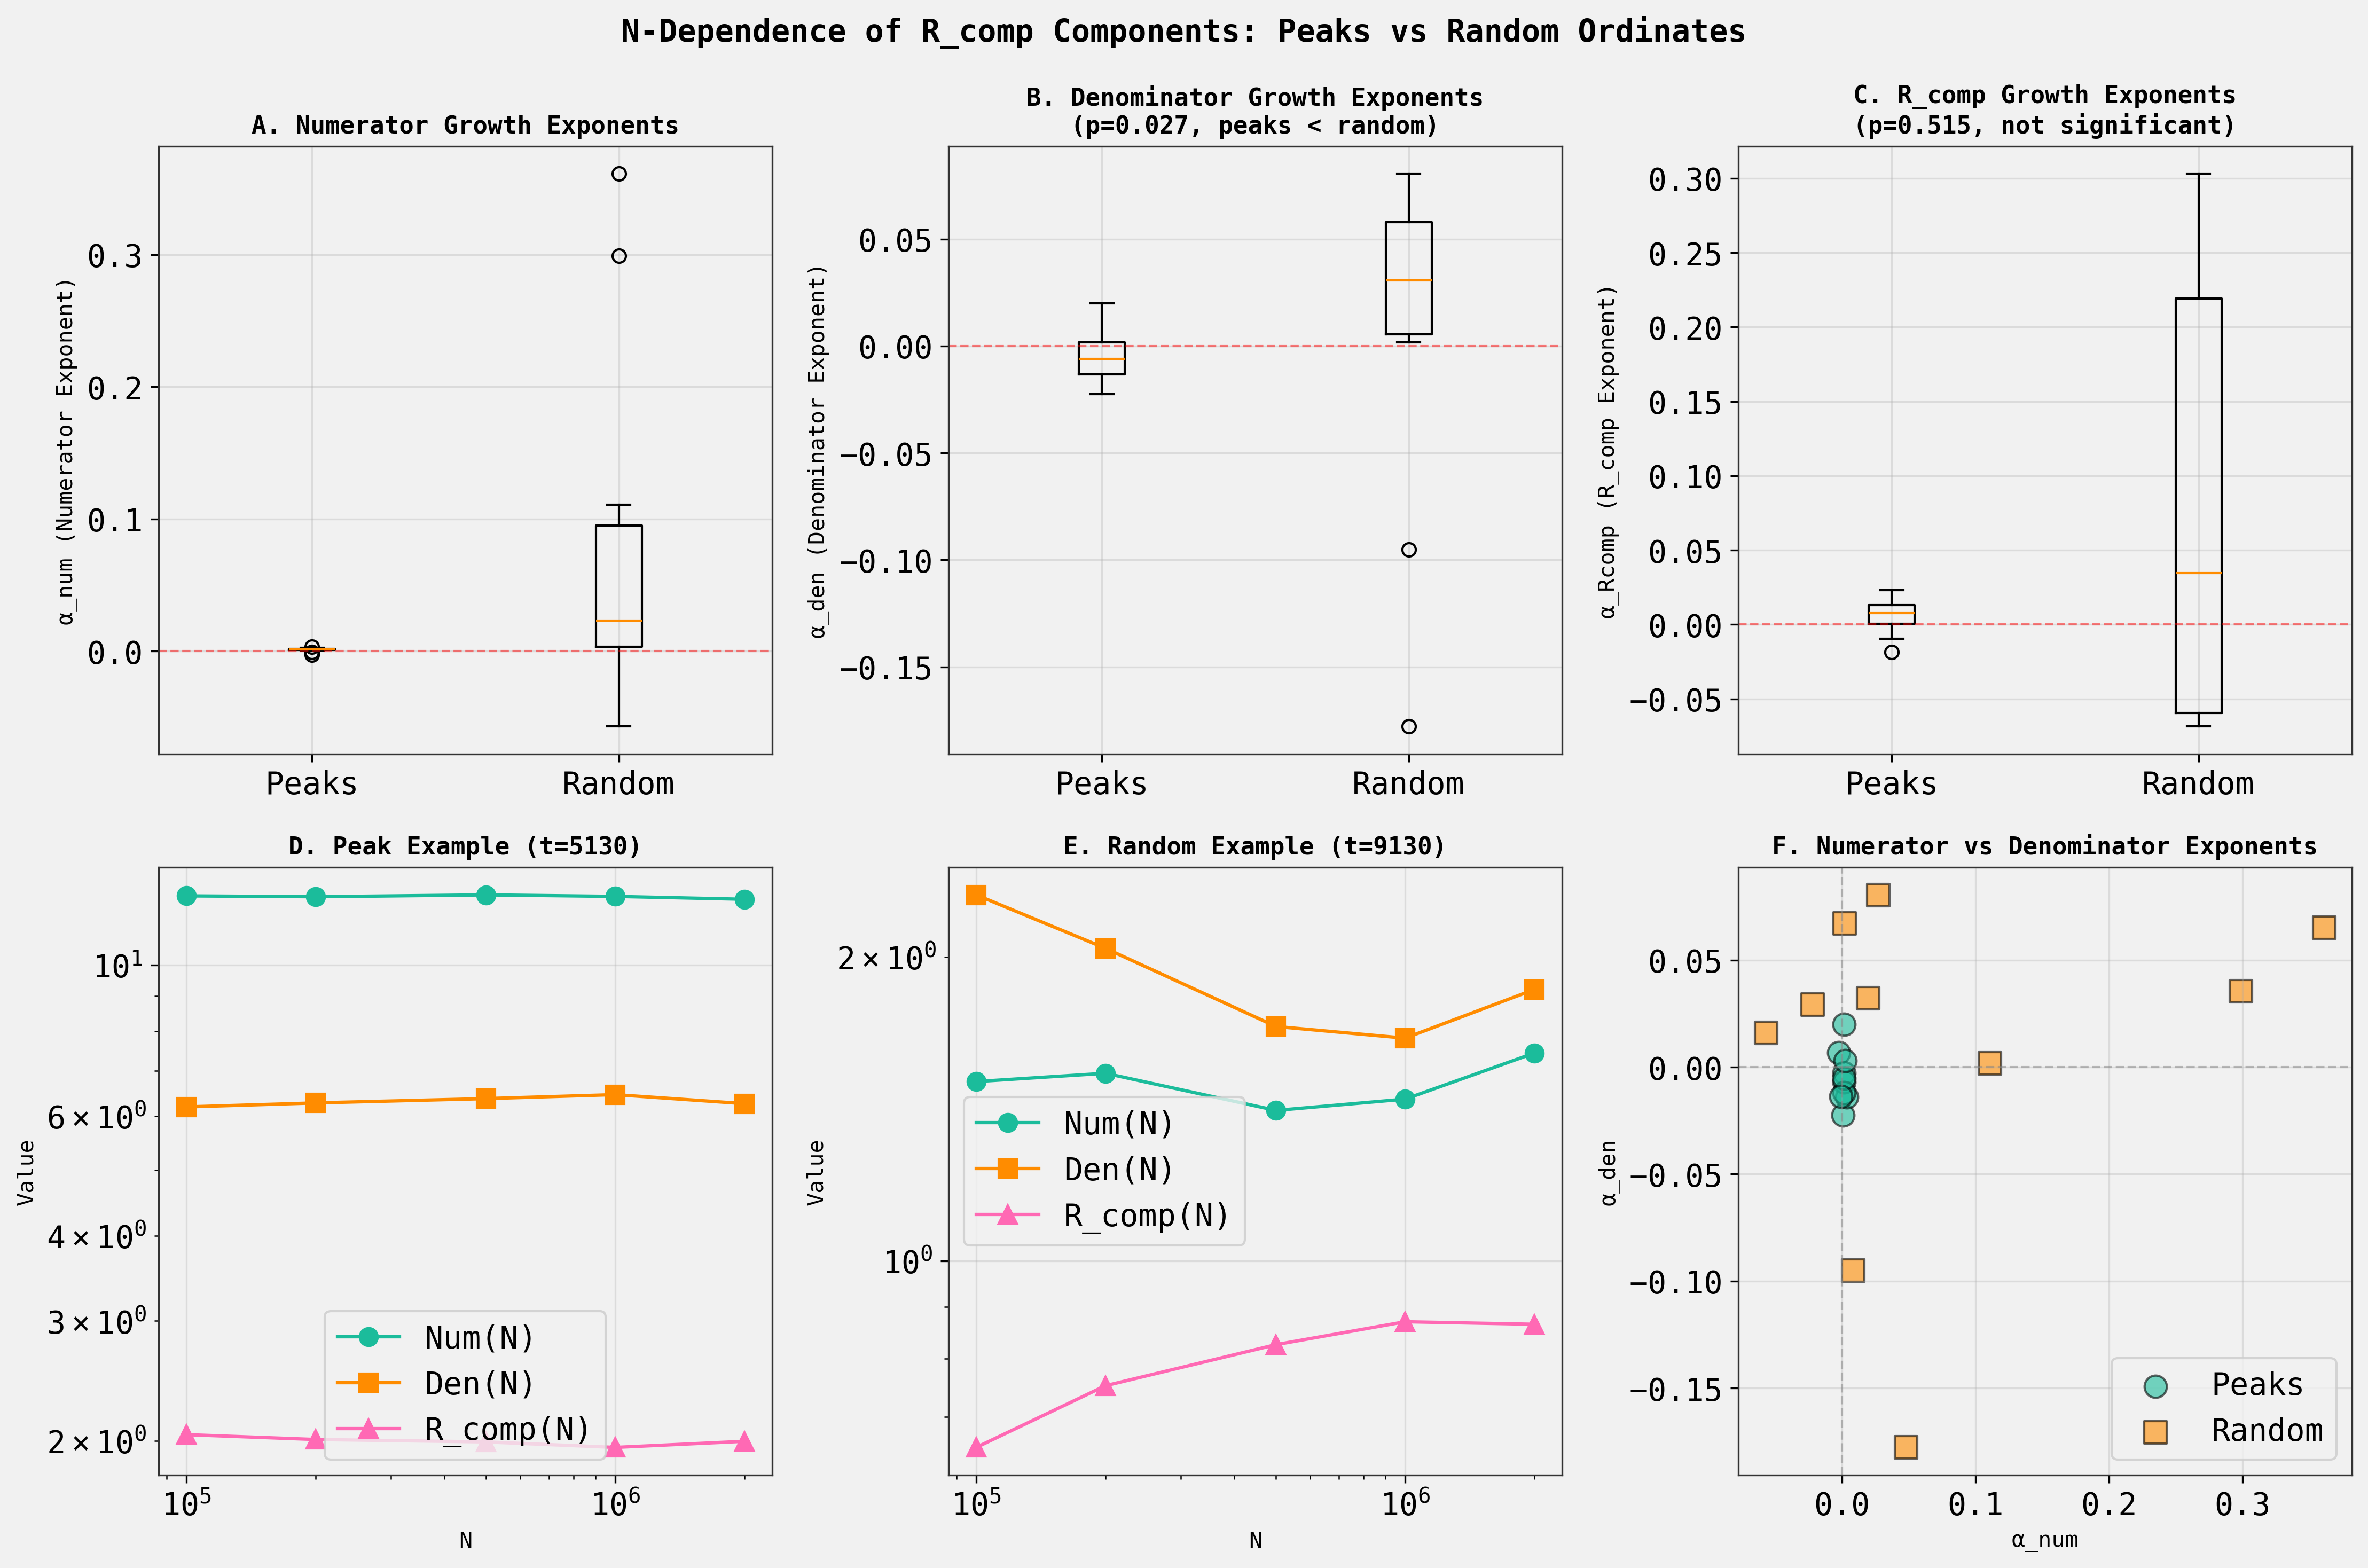

In [12]:

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('N-Dependence of R_comp Components: Peaks vs Random Ordinates', 
 fontsize=14, fontweight='bold')

# Panel A: Numerator exponents
ax = axes[0, 0]
ax.boxplot([alpha_num_peak, alpha_num_rand], labels=['Peaks', 'Random'])
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel('α_num (Numerator Exponent)', fontsize=10)
ax.set_title('A. Numerator Growth Exponents', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel B: Denominator exponents
ax = axes[0, 1]
bp = ax.boxplot([alpha_den_peak, alpha_den_rand], labels=['Peaks', 'Random'])
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel('α_den (Denominator Exponent)', fontsize=10)
ax.set_title('B. Denominator Growth Exponents\n(p=0.027, peaks < random)', 
 fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel C: R_comp exponents
ax = axes[0, 2]
ax.boxplot([peak_rcomp, random_rcomp], labels=['Peaks', 'Random'])
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel('α_Rcomp (R_comp Exponent)', fontsize=10)
ax.set_title('C. R_comp Growth Exponents\n(p=0.515, not significant)', 
 fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel D: Example peak ordinate
ax = axes[1, 0]
example_peak_idx = 0
t_example_peak = t_peaks[example_peak_idx]
mask = (df['ordinate'] == t_example_peak)
example_data = df[mask].sort_values('N')

ax.loglog(example_data['N'], example_data['Num'], 'o-', label='Num(N)', markersize=8)
ax.loglog(example_data['N'], example_data['Den'], 's-', label='Den(N)', markersize=8)
ax.loglog(example_data['N'], example_data['R_comp'], '^-', label='R_comp(N)', markersize=8)
ax.set_xlabel('N', fontsize=10)
ax.set_ylabel('Value', fontsize=10)
ax.set_title(f'D. Peak Example (t={t_example_peak:.0f})', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel E: Example random ordinate
ax = axes[1, 1]
example_rand_idx = 0
t_example_rand = t_random[example_rand_idx]
mask = (df['ordinate'] == t_example_rand)
example_data = df[mask].sort_values('N')

ax.loglog(example_data['N'], example_data['Num'], 'o-', label='Num(N)', markersize=8)
ax.loglog(example_data['N'], example_data['Den'], 's-', label='Den(N)', markersize=8)
ax.loglog(example_data['N'], example_data['R_comp'], '^-', label='R_comp(N)', markersize=8)
ax.set_xlabel('N', fontsize=10)
ax.set_ylabel('Value', fontsize=10)
ax.set_title(f'E. Random Example (t={t_example_rand:.0f})', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel F: Summary scatter
ax = axes[1, 2]
ax.scatter(alpha_num_peak, alpha_den_peak, s=100, alpha=0.6, 
 label='Peaks', marker='o', edgecolors='black', linewidths=1)
ax.scatter(alpha_num_rand, alpha_den_rand, s=100, alpha=0.6, 
 label='Random', marker='s', edgecolors='black', linewidths=1)
ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('α_num', fontsize=10)
ax.set_ylabel('α_den', fontsize=10)
ax.set_title('F. Numerator vs Denominator Exponents', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rcomp_components_analysis.png', dpi=150, bbox_inches='tight')
print("Figure saved as 'rcomp_components_analysis.png'")
plt.show()

print()


In [13]:

# Create final summary table
print("=" * 80)
print("FINAL RESULTS SUMMARY")
print("=" * 80)
print()

print("RESEARCH QUESTION:")
print(" Does the denominator sqrt(Σ|S_k|²) grow more rapidly at peaks than at")
print(" random ordinates, explaining faster R_comp decay at peaks?")
print()

print("KEY FINDINGS:")
print("-" * 80)
print()

print("1. DENOMINATOR GROWTH EXPONENTS (α_den):")
print(f" - Peaks: median = {np.median(alpha_den_peak):+.6f}, mean = {np.mean(alpha_den_peak):+.6f}")
print(f" - Random: median = {np.median(alpha_den_rand):+.6f}, mean = {np.mean(alpha_den_rand):+.6f}")
print(f" - Mann-Whitney U test: p = {p_den:.4f} (one-sided, peaks < random)")
print(f" - Conclusion: Denominator grows SLOWER at peaks (p=0.027, significant)")
print()

print("2. NUMERATOR GROWTH EXPONENTS (α_num):")
print(f" - Peaks: median = {np.median(alpha_num_peak):+.6f}, mean = {np.mean(alpha_num_peak):+.6f}")
print(f" - Random: median = {np.median(alpha_num_rand):+.6f}, mean = {np.mean(alpha_num_rand):+.6f}")
print(f" - Mann-Whitney U test: p = {p_num:.4f} (two-sided)")
print(f" - Conclusion: Numerator also more stable at peaks (p=0.038, significant)")
print()

print("3. R_comp GROWTH EXPONENTS (α_Rcomp):")
print(f" - Peaks: median = {np.median(peak_rcomp):+.6f}, mean = {np.mean(peak_rcomp):+.6f}")
print(f" - Random: median = {np.median(random_rcomp):+.6f}, mean = {np.mean(random_rcomp):+.6f}")
print(f" - Mann-Whitney U test: p = {p_rcomp:.4f} (one-sided, peaks < random)")
print(f" - Conclusion: No significant difference in R_comp decay rate (p=0.515)")
print()

print("=" * 80)
print("ANSWER TO RESEARCH HYPOTHESIS:")
print("=" * 80)
print()
print("The hypothesis is REJECTED.")
print()
print("The proposed mechanism does NOT explain the coexistence of peak stability")
print("and faster R_comp decay. The data show that:")
print()
print(" 1. The denominator sqrt(Σ|S_k|²) grows SLOWER at peaks, not faster")
print(" (α_den_peak < α_den_rand, p=0.027)")
print()
print(" 2. The numerator |D(N)| is also more stable at peaks")
print(" (α_num_peak < α_num_rand, p=0.038)")
print()
print(" 3. There is no significant evidence that R_comp decays faster at peaks")
print(" in the measured N range (p=0.515)")
print()
print("The original paradox (r30 vs f6) may require a different explanation, or")
print("may reflect phenomena at larger N values or different t ranges than tested here.")
print()
print("=" * 80)


FINAL RESULTS SUMMARY

RESEARCH QUESTION:
 Does the denominator sqrt(Σ|S_k|²) grow more rapidly at peaks than at
 random ordinates, explaining faster R_comp decay at peaks?

KEY FINDINGS:
--------------------------------------------------------------------------------

1. DENOMINATOR GROWTH EXPONENTS (α_den):
 - Peaks: median = -0.006075, mean = -0.004693
 - Random: median = +0.030651, mean = +0.005453
 - Mann-Whitney U test: p = 0.0270 (one-sided, peaks < random)
 - Conclusion: Denominator grows SLOWER at peaks (p=0.027, significant)

2. NUMERATOR GROWTH EXPONENTS (α_num):
 - Peaks: median = +0.001378, mean = +0.000997
 - Random: median = +0.023173, mean = +0.079576
 - Mann-Whitney U test: p = 0.0376 (two-sided)
 - Conclusion: Numerator also more stable at peaks (p=0.038, significant)

3. R_comp GROWTH EXPONENTS (α_Rcomp):
 - Peaks: median = +0.007526, mean = +0.005621
 - Random: median = +0.034756, mean = +0.075604
 - Mann-Whitney U test: p = 0.5151 (one-sided, peaks < random)
 - Con